# Train price classifier model

In [1]:
# pip install pandas scikit-learn catboost seaborn matplotlib

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [22]:
listings_df = pd.read_csv('./listings_df.csv')

In [23]:
listings_df.head(10)

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839
4,5,31,18,1,100000.00,NaN,2026-04-24 18:12:51.718141,2026-04-24 18:12:51.718144
5,6,30,6,1,67.00,NaN,2026-04-24 18:14:05.652592,2026-04-29 17:47:16.647595
6,7,32,18,1,150000.00,NaN,2026-04-24 18:14:20.493645,2026-04-24 18:14:20.493647
7,8,33,18,2,50000.00,eaeefe0d17ce643277365ba9430d3a72dfc393b6239fff...,2026-04-24 18:15:32.819267,2026-04-27 06:29:55.606166
8,9,35,6,1,1488.00,NaN,2026-04-24 18:16:12.344887,2026-04-29 17:47:16.649940
9,10,19,1,2,12.00,b48b068238890641300048c1fe0baf3f5bbb8583123917...,2026-04-24 18:20:15.784456,2026-04-27 06:29:58.680969


In [24]:
presents_df = pd.read_csv('./presents_df.csv')
presents_df.head(10)

,present_id,collection_id,model_id,background_id,symbol_id,present_num,image_url,generated_at,is_burned,description,is_visible,original_sender_id
0,2,1,29.00,17.00,481.00,1,generated_e59baadbf09b4917bd650259802ba622.png,2026-04-27 05:51:06.286198,0,NaN,1,2
1,3,5,323.00,32.00,394.00,1,generated_4185562bc2cb4ce29d9799af7785c79b.png,2026-04-24 09:59:46.440513,0,ура 2025,1,1
2,4,58,3904.00,43.00,45.00,1,generated_a7ed190fec4e4cb590a257329302fba6.png,2026-04-24 09:59:49.045898,0,хехе хитрый тыква,1,1
3,5,30,1958.00,67.00,670.00,1,generated_767b7f36261545118c696d87bdf72a9f.png,2026-04-24 18:22:35.635907,0,держи какаху #1,0,1
4,6,4,255.00,23.00,285.00,1,generated_96b6ed21e12f4bf5a1e888b0ba13a515.png,2026-04-27 05:51:09.289261,0,клубничка для сладенькой,1,1
5,7,11,642.00,56.00,368.00,1,generated_b2c81be3986a4c3da3f1aab4ea87177a.png,2026-04-24 09:59:38.092433,0,на удачу найти блондинку,1,2
6,8,16,1055.00,77.00,24.00,1,generated_83a9c292bbc7469ba040261f1ba1ec34.png,2026-04-24 09:59:40.858993,0,выходи за меня,1,2
7,9,10,601.00,18.00,627.00,1,generated_75fe808b3e3a45868cafe76f64e057e9.png,2026-04-24 18:22:49.683475,0,пососи,0,2
8,11,4,NaN,NaN,NaN,2,berry_box,2026-04-04 11:36:32.991914,1,урааа,0,2
9,12,4,253.00,63.00,479.00,3,generated_a4604da677c049c2a91b0a883402315c.png,2026-04-27 05:51:12.749094,0,тестим жестко,1,2


In [25]:
collections_df = pd.read_csv('./collections_df.csv')
collections_df.head(10)

,collection_id,collection_name,collection_image_url,collection_limit,purchase_limit,base_price,is_active,created_at,updated_at
0,1,Artisan Brick,artisan_brick,7000,5,20.00,1,2026-03-22 23:06:54.901582,2026-03-22 23:06:54.901582
1,2,Astral Shard,astral_shard,10000,5,2.00,1,2026-03-22 23:06:54.907084,2026-03-22 23:06:54.907084
2,3,B-day Candle,b_day_candle,500000,5,2.00,1,2026-03-22 23:06:54.910604,2026-03-22 23:06:54.910604
3,4,Berry Box,berry_box,100000,5,1.00,1,2026-03-22 23:06:54.913986,2026-03-22 23:06:54.913986
4,5,Big Year,big_year,200000,5,1.00,1,2026-03-22 23:06:54.918053,2026-03-22 23:06:54.918053
5,6,Bling Binky,bling_binky,10000,5,25.00,1,2026-03-22 23:06:54.921403,2026-03-22 23:06:54.921403
6,7,Bonded Ring,bonded_ring,9000,5,21.00,1,2026-03-22 23:06:54.924826,2026-03-22 23:06:54.924826
7,8,Bow Tie,bow_tie,100000,5,2.00,1,2026-03-22 23:06:54.928361,2026-03-22 23:06:54.928361
8,9,Bunny Muffin,bunny_muffin,100000,5,1.00,1,2026-03-22 23:06:54.932232,2026-03-22 23:06:54.932232
9,10,Candy Cane,candy_cane,600000,5,1.00,1,2026-03-22 23:06:54.935372,2026-03-22 23:06:54.935372


In [26]:
df = pd.merge(listings_df, presents_df, on='present_id')
df = pd.merge(df, collections_df[['collection_id', 'collection_limit']], on='collection_id')
df.head(10)

,listing_id,present_id,seller_id,status_id,price,blockchain_tx_hash,created_at,updated_at,collection_id,model_id,background_id,symbol_id,present_num,image_url,generated_at,is_burned,description,is_visible,original_sender_id,collection_limit
0,1,17,1,2,2.00,44076831bdfb9c10eea4609ac5d5efc0f7c8d8c32d2115...,2026-04-24 10:04:33.860784,2026-04-24 16:18:44.994410,5,308.00,27.00,338.00,2,generated_5f1379395227444281a0a116cc8548e2.png,2026-04-24 09:59:43.377860,0,chinazes,1,1,200000
1,2,22,16,1,10.00,NaN,2026-04-24 17:27:27.979196,2026-04-29 17:47:16.651635,1,20.00,17.00,415.00,3,generated_f7c5562272af43a3a898442ae8dd31ed.png,2026-04-24 17:27:00.751121,0,дл,1,16,7000
2,3,28,17,2,1502.00,15e795d6ae3a855f9f7cc68d10abcff318e52244a016bb...,2026-04-24 18:00:12.182984,2026-04-27 06:27:20.077044,1,53.00,22.00,97.00,4,generated_4387cd1622974b468ec9fe550f22e767.png,2026-04-24 18:00:03.660896,0,NaN,1,17,7000
3,4,29,17,2,0.01,6131fa4789dbb73b4e9e405e303b61d380f0d99caa1725...,2026-04-24 18:01:52.627305,2026-04-27 06:29:50.453839,107,6903.00,28.00,716.00,1,generated_9124141b847c4677b0675e523ea613d1.png,2026-04-24 18:01:31.837272,0,СВЭГ,1,1,12000
4,5,31,18,1,100000.00,NaN,2026-04-24 18:12:51.718141,2026-04-24 18:12:51.718144,71,4641.00,56.00,36.00,2,generated_0352d847cd53454f9f31cc3a1a9d1117.png,2026-04-24 18:10:05.684851,0,ПЭПЭ ШЕНЭЙНЕ,1,1,3000
5,6,30,6,1,67.00,NaN,2026-04-24 18:14:05.652592,2026-04-29 17:47:16.647595,96,6238.00,42.00,602.00,1,generated_a6d7baf07f4342de803e885debf89a60.png,2026-04-24 18:12:38.529762,0,прародитель сваги,1,1,240000
6,7,32,18,1,150000.00,NaN,2026-04-24 18:14:20.493645,2026-04-24 18:14:20.493647,67,4413.00,75.00,327.00,1,generated_ceb9449629244760bb4dbca822d44e91.png,2026-04-24 18:13:57.921828,0,NaN,1,18,18000
7,8,33,18,2,50000.00,eaeefe0d17ce643277365ba9430d3a72dfc393b6239fff...,2026-04-24 18:15:32.819267,2026-04-27 06:29:55.606166,87,5627.00,60.00,286.00,1,generated_d2de7fd17a304b8e899bcedd88eced64.png,2026-04-24 18:15:08.389765,0,NaN,1,18,120000
8,9,35,6,1,1488.00,NaN,2026-04-24 18:16:12.344887,2026-04-29 17:47:16.649940,30,1989.00,26.00,420.00,2,generated_5a2a1126e0c24668ac23921ca2b9cb2e.png,2026-04-24 18:15:41.824608,0,лови какаху,1,1,300000
9,10,19,1,2,12.00,b48b068238890641300048c1fe0baf3f5bbb8583123917...,2026-04-24 18:20:15.784456,2026-04-27 06:29:58.680969,3,209.00,66.00,496.00,1,generated_9b2743cfec1747b48ba41a96e2c23a5c.png,2026-04-24 09:59:06.788923,0,хэпи бездэй),1,2,500000


Columns listing_id, seller_id, status_id, blockchain_tx_hash, created_at, updated_at, image_url, generated_at, is_burned, description, is_visible, original_sender_id not needed. We'll drop them.

In [27]:
df = df.drop(columns=['present_id', 'listing_id', 'seller_id', 'blockchain_tx_hash', 'created_at', 'updated_at', 'image_url', 'generated_at', 'is_burned', 'description', 'is_visible', 'original_sender_id'])

In [28]:
df.head()

,status_id,price,collection_id,model_id,background_id,symbol_id,present_num,collection_limit
0,2,2.00,5,308.00,27.00,338.00,2,200000
1,1,10.00,1,20.00,17.00,415.00,3,7000
2,2,1502.00,1,53.00,22.00,97.00,4,7000
3,2,0.01,107,6903.00,28.00,716.00,1,12000
4,1,100000.00,71,4641.00,56.00,36.00,2,3000


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
status_id,321.00,1.59,0.78,1.00,1.00,1.00,2.00,3.00
price,321.00,7498967.63,127609948.75,0.01,3.00,13.00,66.00,2283371488.00
collection_id,321.00,44.41,34.51,1.00,11.00,38.00,71.00,109.00
model_id,321.00,2900.07,2261.37,13.00,636.00,2509.00,4660.00,6987.00
background_id,321.00,39.62,22.77,1.00,22.00,39.00,59.00,79.00
symbol_id,321.00,362.55,194.38,2.00,226.00,366.00,496.00,716.00
present_num,321.00,2.72,2.37,1.00,1.00,2.00,4.00,12.00
collection_limit,321.00,109828.66,132607.10,2000.00,10000.00,40000.00,200000.00,600000.00


In [30]:
df = df[df['price'] < 10000]
df = df[df['price'] > 0.5]
df = df[df['status_id'] == 1]

In [31]:
cat_features = ['collection_id', 'model_id', 'background_id', 'symbol_id']
num_features = ['present_num', 'collection_limit']

X = df[cat_features + num_features].copy()
y = df['price'].copy()

for col in cat_features:
    X[col] = X[col].astype('Int64').astype(str)

In [32]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
status_id,187.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
price,187.00,82.73,149.24,1.00,5.00,27.00,99.00,1488.00
collection_id,187.00,48.24,32.65,1.00,20.50,48.00,72.00,109.00
model_id,187.00,3154.18,2141.83,20.00,1374.00,3220.00,4711.50,6987.00
background_id,187.00,38.44,23.83,1.00,15.50,39.00,58.00,79.00
symbol_id,187.00,358.42,198.28,2.00,193.50,363.00,509.00,716.00
present_num,187.00,3.23,2.42,1.00,1.00,2.00,5.00,12.00
collection_limit,187.00,108288.77,132223.06,2000.00,10000.00,35000.00,180000.00,600000.00


In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 187 entries, 1 to 320
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         187 non-null    int64  
 1   price             187 non-null    float64
 2   collection_id     187 non-null    int64  
 3   model_id          187 non-null    float64
 4   background_id     187 non-null    float64
 5   symbol_id         187 non-null    float64
 6   present_num       187 non-null    int64  
 7   collection_limit  187 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 13.1 KB


<Axes: >

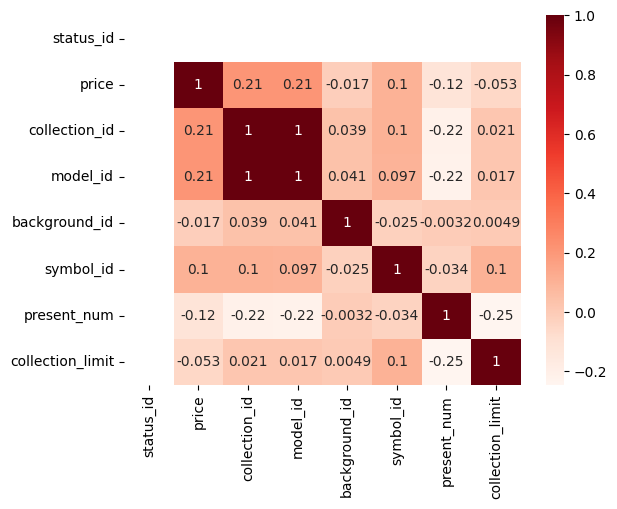

In [34]:
sns.heatmap(df.corr(), annot=True, cmap='Reds')

# Train

In [35]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor as cbr
from sklearn.metrics import mean_squared_error

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [37]:
cbr_model = cbr(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=False,
    random_seed=42
)
cbr_model.fit(X_train, Y_train, cat_features=cat_features)

CatBoostRegressor(depth=4, iterations=300, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [38]:
y_pred = cbr_model.predict(X_test)

In [39]:
from sklearn import metrics

In [40]:
print('r2score', metrics.r2_score(Y_test, y_pred))

r2score 0.20830138379676966
